In [2]:
# !venv/bin/python add_surtkey_columns.py --db-path data/12_transportation/cdxj.duckdb


In [3]:
import duckdb
import pandas as pd

from domain_analysis import (
    base_domain_sql,
    subdomain_sql,
    build_domain_summary,
    build_subdomain_breakdown,
)

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 80)

# DB has been migrated with add_surtkey_columns.py:
#   surthost, surthost_seg_0..5, surtpath_1..5
transport_con = duckdb.connect('data/12_transportation/cdxj.duckdb', read_only=True)

TARGET_DOMAINS = [
    'usda.gov', 'commerce.gov', 'defense.gov', 'ed.gov', 'energy.gov',
    'hhs.gov', 'dhs.gov', 'hud.gov', 'doi.gov', 'justice.gov',
    'dol.gov', 'state.gov', 'transportation.gov', 'treasury.gov', 'va.gov',
]

print('Connected.')

Connected.


In [4]:
transport_con.sql("SELECT COUNT(*) FROM eot_captures").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       787021 │
└──────────────┘



In [5]:
# Total captures per year
# NOTE: no 2012 data in the per-domain DB, so 2012 is missing here
transport_con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1 ORDER BY 1
""").show()

┌────────────┬──────────┐
│ crawl_year │ captures │
│  varchar   │  int64   │
├────────────┼──────────┤
│ 2004       │        8 │
│ 2008       │      185 │
│ 2016       │   199393 │
│ 2020       │   587435 │
└────────────┴──────────┘



In [6]:
# host, year, count
transport_con.sql("""
    SELECT host, crawl_year, COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
    ORDER BY n DESC
""").show(max_rows=50)

┌────────────────────────────┬────────────┬────────┐
│            host            │ crawl_year │   n    │
│          varchar           │  varchar   │ int64  │
├────────────────────────────┼────────────┼────────┤
│ data.transportation.gov    │ 2020       │ 503223 │
│ www.transportation.gov     │ 2016       │ 179119 │
│ www.transportation.gov     │ 2020       │  77070 │
│ data.transportation.gov    │ 2016       │  20274 │
│ www7.transportation.gov    │ 2020       │   5694 │
│ datahub.transportation.gov │ 2020       │   1433 │
│ www.transportation.gov     │ 2008       │    140 │
│ transportation.gov         │ 2008       │     45 │
│ transportation.gov         │ 2020       │     15 │
│ www.transportation.gov     │ 2004       │      8 │
├────────────────────────────┴────────────┴────────┤
│ 10 rows                                3 columns │
└──────────────────────────────────────────────────┘



### SURT host columns — materialized via `add_surtkey_columns.py`

The DB now carries `surthost`, `surthost_seg_0..5`, and `surtpath_1..5` as physical columns
parsed from the SURT key. We can query them directly instead of regex-extracting from `surtkey`.

**Heads up:** SURT canonicalization strips a leading `www`, so `www.transportation.gov` rows
have the same `surthost` as bare `transportation.gov` (`gov,transportation`) and their
`surthost_seg_2` is NULL.

In [7]:
# Show the new columns populated against a few representative hosts
transport_con.sql("""
    SELECT host, surthost,
           surthost_seg_0 AS tld,
           surthost_seg_1 AS reg_dom,
           surthost_seg_2 AS sub1,
           surthost_seg_3 AS sub2,
           surtpath_1, surtpath_2
    FROM eot_captures
    WHERE host IN ('www.transportation.gov', 'data.transportation.gov',
                   'www7.transportation.gov', 'datahub.transportation.gov')
    LIMIT 8
""").show()


┌────────────────────────┬────────────────────┬─────────┬────────────────┬─────────┬─────────┬────────────┬────────────┐
│          host          │      surthost      │   tld   │    reg_dom     │  sub1   │  sub2   │ surtpath_1 │ surtpath_2 │
│        varchar         │      varchar       │ varchar │    varchar     │ varchar │ varchar │  varchar   │  varchar   │
├────────────────────────┼────────────────────┼─────────┼────────────────┼─────────┼─────────┼────────────┼────────────┤
│ www.transportation.gov │ gov,transportation │ gov     │ transportation │ NULL    │ NULL    │            │ NULL       │
│ www.transportation.gov │ gov,transportation │ gov     │ transportation │ NULL    │ NULL    │ robots.txt │ NULL       │
│ www.transportation.gov │ gov,transportation │ gov     │ transportation │ NULL    │ NULL    │            │ NULL       │
│ www.transportation.gov │ gov,transportation │ gov     │ transportation │ NULL    │ NULL    │ robots.txt │ NULL       │
│ www.transportation.gov │ gov,t

### DomainDataSummary — high-level domain structure (SURT-derived)

In [8]:
# Per-domain roll-up parsed from surtkey (no hardcoded host list).
domain_summary = build_domain_summary(transport_con)
domain_summary


,base_domain,total_captures,unique_subdomains,years_covered,top_subdomain,top_subdomain_count,bare_captures,pct_bare
0,transportation.gov,787021,3,4,data,523497,262091.0,33.3


In [9]:
# Full subdomain breakdown — uses materialized surthost_seg_2 column directly.
# Note: surthost_seg_2 is the innermost subdomain label after SURT canonicalization
# (so 'www.foo.gov' rows fold into NULL→'(bare/www)' alongside bare 'foo.gov').
subdomain_df = transport_con.sql("""
    SELECT
        COALESCE(surthost_seg_2, '(bare/www)') AS subdomain,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE surtkey IS NOT NULL
    GROUP BY 1, 2
""").df()

subdomain_pivot = (subdomain_df
    .pivot_table(index='subdomain', columns='crawl_year', values='n', aggfunc='sum')
    .fillna(0).astype(int))
subdomain_pivot['total'] = subdomain_pivot.sum(axis=1)
subdomain_pivot = subdomain_pivot.sort_values('total', ascending=False).head(30)

total_subs = transport_con.sql("""
    SELECT COUNT(DISTINCT COALESCE(surthost_seg_2, '(bare/www)'))
    FROM eot_captures WHERE surtkey IS NOT NULL
""").fetchone()[0]
print(f"Total unique top-level subdomain labels (surthost_seg_2): {total_subs:,}")
subdomain_pivot


Total unique top-level subdomain labels (surthost_seg_2): 3


crawl_year,2004,2008,2016,2020,total
subdomain,,,,,
data,0,0,20274,503223,523497
(bare/www),8,185,179119,82779,262091
datahub,0,0,0,1433,1433


In [ ]:
# Position 1 (surtpath_1) — ranked per year
seg1 = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(root)') AS seg1,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

seg1_pivot = seg1.pivot(index='seg1', columns='crawl_year', values='n').fillna(0).astype(int)
seg1_pivot['total'] = seg1_pivot.sum(axis=1)
seg1_pivot = seg1_pivot.sort_values('total', ascending=False)
seg1_pivot

In [11]:
seg1_pivot.head(50)

crawl_year,2004,2008,2016,2020,total
seg1,,,,,
browse,0,0,1428,499251,500679
sites,0,0,28311,14833,43144
osdbu,0,0,36559,2569,39128
feedback,0,0,15957,12807,28764
node,0,0,17243,2871,20114
comment,0,0,16280,0,16280
print,0,0,5542,7132,12674
OData.svc,0,0,9823,0,9823
taxonomy,0,0,2276,5514,7790


In [12]:
seg1_pivot[seg1_pivot[['2004', '2008']].sum(axis=1) > 0][['2004', '2008', 'total']].sort_values('2004', ascending=False)


crawl_year,2004,2008,total
seg1,,,
robots.txt,4,6,3455
(root),4,6,82
text,0,3,3
1.3.7,0,2,2
wtinit.js,0,2,2
wtbase.js,0,2,2
dotstyles.css,0,2,2
DCS.dcsqry,0,3,3
DCS.dcssip,0,3,3


In [13]:
seg1_pivot[seg1_pivot[['2016']].sum(axis=1) > 0][['2016', 'total']].sort_values('2016', ascending=False)


crawl_year,2016,total
seg1,,
osdbu,36559,39128
sites,28311,43144
node,17243,20114
comment,16280,16280
feedback,15957,28764
...,...,...
Jon%20Moss.jpg,1,1
Lowestfare.com,1,1
mtp,1,1


In [ ]:
# Position 2 (surtpath_2) — ranked per year
seg2 = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3
""").df()

seg2_pivot = seg2.pivot_table(index=['seg1', 'seg2'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg2_pivot['total'] = seg2_pivot.sum(axis=1)
seg2_pivot = seg2_pivot.sort_values('total', ascending=False)
seg2_pivot

In [ ]:
# Position 3 (surtpath_3) — ranked per year
seg3 = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(surtpath_3, ''), '(none)') AS seg3,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4
""").df()

seg3_pivot = seg3.pivot_table(index=['seg1', 'seg2', 'seg3'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg3_pivot['total'] = seg3_pivot.sum(axis=1)
seg3_pivot = seg3_pivot.sort_values('total', ascending=False)
seg3_pivot

In [ ]:
# Position 4 (surtpath_4) — ranked per year
seg4 = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(surtpath_3, ''), '(none)') AS seg3,
        COALESCE(NULLIF(surtpath_4, ''), '(none)') AS seg4,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4, 5
""").df()

seg4_pivot = seg4.pivot_table(index=['seg1', 'seg2', 'seg3', 'seg4'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg4_pivot['total'] = seg4_pivot.sum(axis=1)
seg4_pivot = seg4_pivot.sort_values('total', ascending=False)
seg4_pivot

In [ ]:
# Position 5 (surtpath_5) — ranked per year
seg5 = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(surtpath_1, ''), '(root)') AS seg1,
        COALESCE(NULLIF(surtpath_2, ''), '(none)') AS seg2,
        COALESCE(NULLIF(surtpath_3, ''), '(none)') AS seg3,
        COALESCE(NULLIF(surtpath_4, ''), '(none)') AS seg4,
        COALESCE(NULLIF(surtpath_5, ''), '(none)') AS seg5,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2, 3, 4, 5, 6
""").df()

seg5_pivot = seg5.pivot_table(index=['seg1', 'seg2', 'seg3', 'seg4', 'seg5'], columns='crawl_year', values='n',
                              aggfunc='sum').fillna(0).astype(int)
seg5_pivot['total'] = seg5_pivot.sum(axis=1)
seg5_pivot = seg5_pivot.sort_values('total', ascending=False)
seg5_pivot

### File Extensions — transportation.gov

In [ ]:
# File extensions — ranked per year
ext_df = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(lower(regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '\\.([a-zA-Z0-9]+)$', 1)), ''), '(none)') AS ext,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

ext_pivot = ext_df.pivot(index='ext', columns='crawl_year', values='n').fillna(0).astype(int)
ext_pivot['total'] = ext_pivot.sum(axis=1)
ext_pivot = ext_pivot.sort_values('total', ascending=False)
ext_pivot

In [19]:
ext_pivot.head(20)

crawl_year,2004,2008,2016,2020,total
ext,,,,,
(none),4,9,87096,564673,651782
js,0,7,42799,1252,44058
css,0,2,26098,745,26845
pdf,0,0,15843,9195,25038
jpg,0,30,5785,2132,7947
gov,0,3,5762,8,5773
png,0,0,2192,2463,4655
txt,4,6,601,3261,3872
html,0,0,1887,58,1945


### Filenames — transportation.gov

In [ ]:
# Filenames — ranked per year
fname_df = transport_con.sql("""
    SELECT
        COALESCE(NULLIF(regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '/([^/]+)$', 1), ''), '(root)') AS filename,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    GROUP BY 1, 2
""").df()

fname_pivot = fname_df.pivot(index='filename', columns='crawl_year', values='n').fillna(0).astype(int)
fname_pivot['total'] = fname_pivot.sum(axis=1)
fname_pivot = fname_pivot.sort_values('total', ascending=False)
fname_pivot

## Visualizations

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

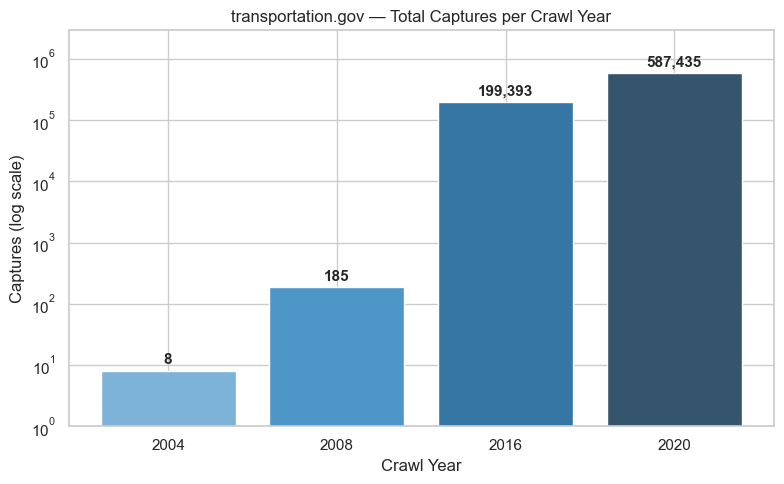

In [22]:
# Viz 1: Captures over time (bar chart, log scale)
year_counts = transport_con.sql("""
    SELECT crawl_year, COUNT(*) AS captures
    FROM eot_captures
    GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(year_counts['crawl_year'], year_counts['captures'], color=sns.color_palette('Blues_d', 4))
ax.set_yscale('log')
ax.set_ylabel('Captures (log scale)')
ax.set_xlabel('Crawl Year')
ax.set_title('transportation.gov — Total Captures per Crawl Year')

for bar, val in zip(bars, year_counts['captures']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(1, year_counts['captures'].max() * 5)
plt.tight_layout()
plt.show()

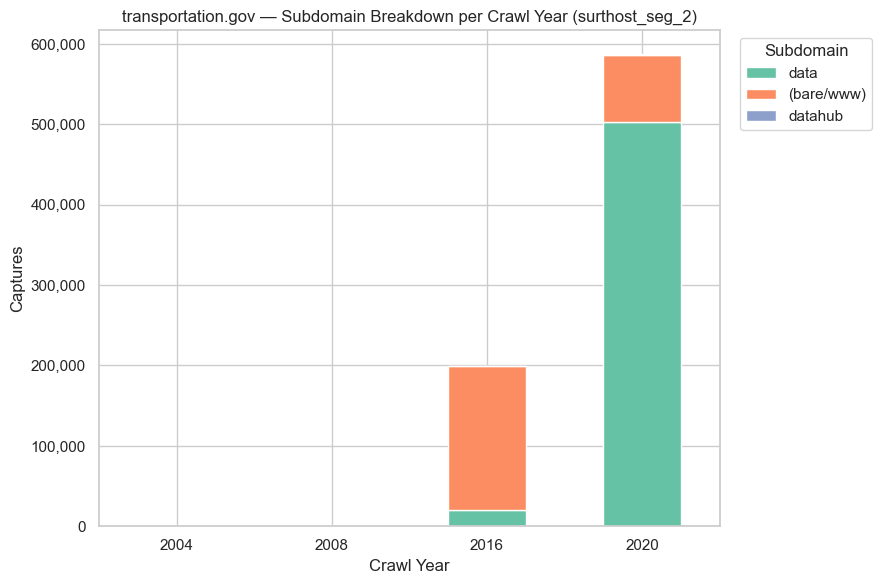

In [23]:
# Viz 2: Subdomain stacked bar — queries surthost_seg_2 directly (no helper, no regex)
host_year = transport_con.sql("""
    SELECT
        COALESCE(surthost_seg_2, '(bare/www)') AS subdomain,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE surtkey IS NOT NULL
    GROUP BY 1, 2
""").df()

totals = host_year.groupby('subdomain')['n'].sum().sort_values(ascending=False)
top_subs = totals.head(8).index.tolist()
host_year['subdomain'] = host_year['subdomain'].where(
    host_year['subdomain'].isin(top_subs), 'other'
)

host_pivot = (host_year.pivot_table(index='crawl_year', columns='subdomain',
                                     values='n', aggfunc='sum')
                       .fillna(0).astype(int))
col_order = [s for s in top_subs if s in host_pivot.columns]
if 'other' in host_pivot.columns:
    col_order.append('other')
host_pivot = host_pivot[col_order]

ax = host_pivot.plot(kind='bar', stacked=True, figsize=(9, 6),
                     color=sns.color_palette('Set2', len(col_order)))
ax.set_ylabel('Captures')
ax.set_xlabel('Crawl Year')
ax.set_title('transportation.gov — Subdomain Breakdown per Crawl Year (surthost_seg_2)')
ax.legend(title='Subdomain', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


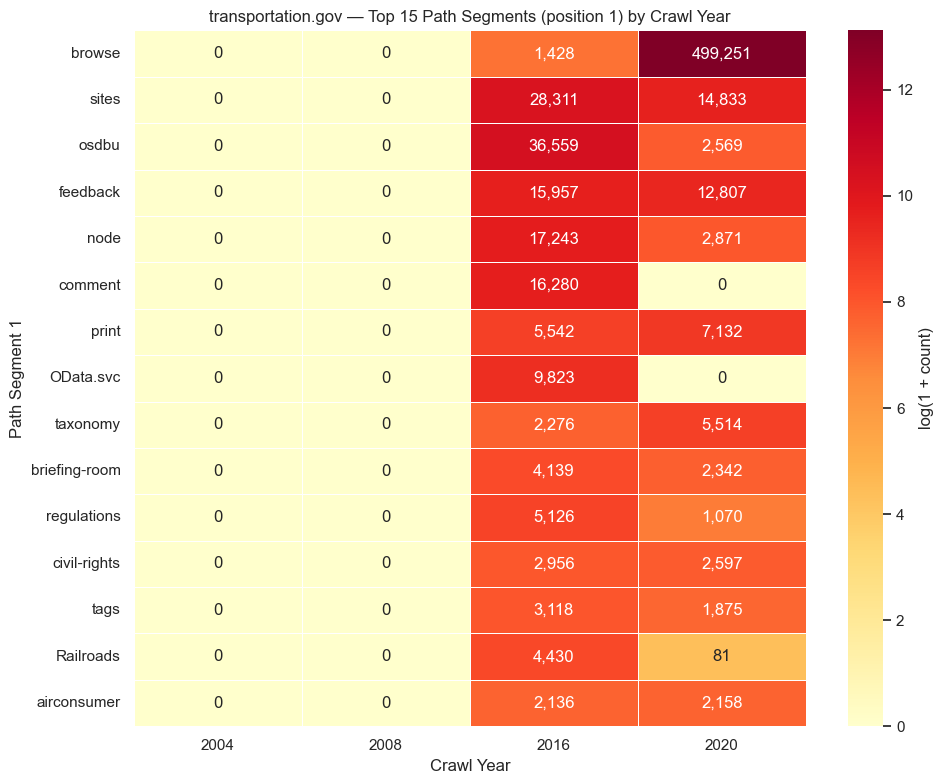

In [24]:
# Viz 3: Top 15 path segment 1 values — heatmap across crawl years
top15 = seg1_pivot[seg1_pivot.index != '(root)'].head(15)
year_cols = [c for c in top15.columns if c != 'total']

fig, ax = plt.subplots(figsize=(10, 8))
data = top15[year_cols].replace(0, np.nan)

sns.heatmap(np.log1p(top15[year_cols]), annot=top15[year_cols].values,
            fmt=',d', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'log(1 + count)'})
ax.set_title('transportation.gov — Top 15 SURT path_1 values by Crawl Year')
ax.set_ylabel('SURT path_1')
ax.set_xlabel('Crawl Year')
plt.tight_layout()
plt.show()

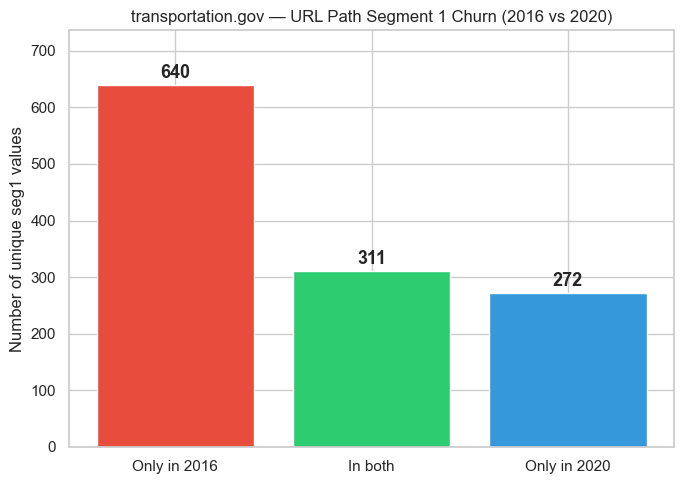

2016 had 951 unique seg1 values, 2020 had 583
640 disappeared, 272 are new, 311 persisted


In [25]:
# Viz 4: Seg1 churn — how many path segments are shared vs unique between 2016 and 2020
in_2016 = set(seg1_pivot[seg1_pivot['2016'] > 0].index)
in_2020 = set(seg1_pivot[seg1_pivot['2020'] > 0].index)

only_2016 = len(in_2016 - in_2020)
only_2020 = len(in_2020 - in_2016)
both = len(in_2016 & in_2020)

churn = pd.DataFrame({
    'category': ['Only in 2016', 'In both', 'Only in 2020'],
    'count': [only_2016, both, only_2020]
})

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.bar(churn['category'], churn['count'], color=colors)
for bar, val in zip(bars, churn['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of unique seg1 values')
ax.set_title('transportation.gov — SURT path_1 Churn (2016 vs 2020)')
ax.set_ylim(0, max(churn['count']) * 1.15)
plt.tight_layout()
plt.show()

print(f"2016 had {len(in_2016)} unique seg1 values, 2020 had {len(in_2020)}")
print(f"{only_2016} disappeared, {only_2020} are new, {both} persisted")

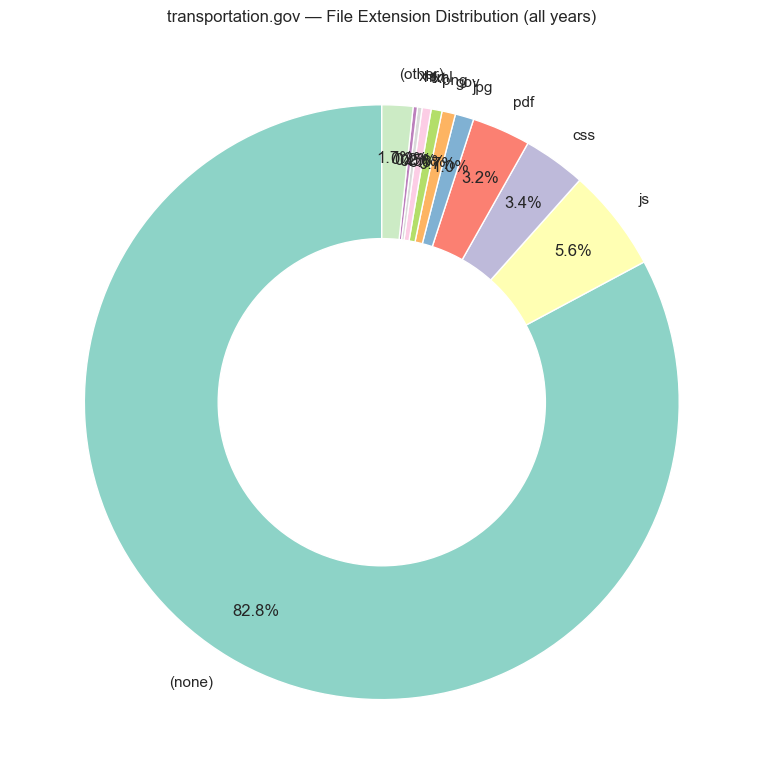

In [26]:
# Viz 5: Extension donut chart — top 10 + other
top_ext = ext_pivot.head(10).copy()
other_total = ext_pivot.iloc[10:]['total'].sum()
other_row = pd.DataFrame({'total': [other_total]}, index=['(other)'])
donut_data = pd.concat([top_ext[['total']], other_row])

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('Set3', len(donut_data))
wedges, texts, autotexts = ax.pie(
    donut_data['total'], labels=donut_data.index, autopct='%1.1f%%',
    colors=colors, pctdistance=0.82, startangle=90
)
centre = plt.Circle((0, 0), 0.55, fc='white')
ax.add_patch(centre)
ax.set_title('transportation.gov — File Extension Distribution (all years)')
plt.tight_layout()
plt.show()

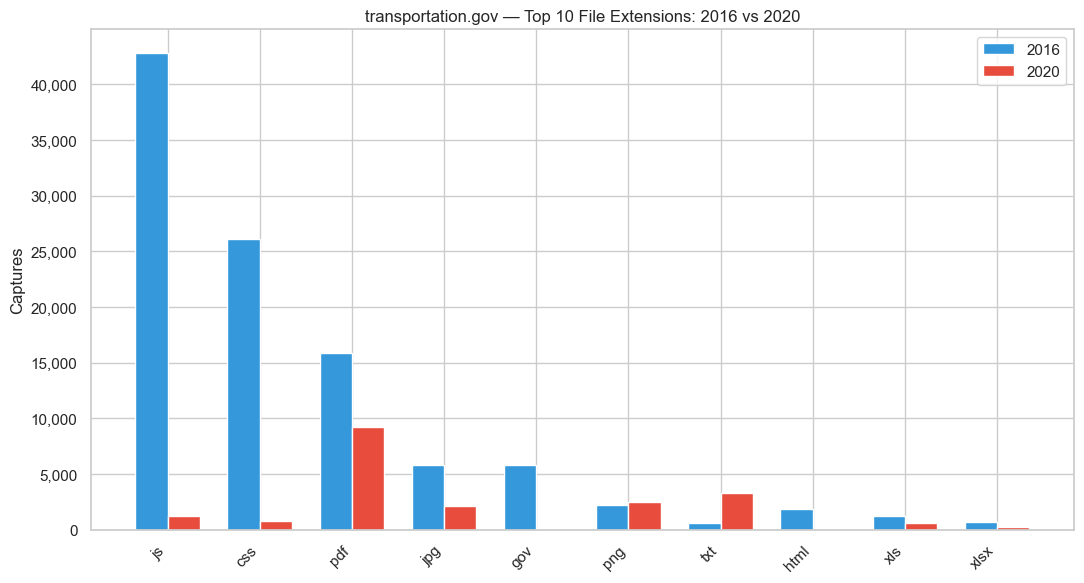

In [27]:
# Viz 6: Extension shift — 2016 vs 2020 (excluding (none))
ext_no_none = ext_pivot[ext_pivot.index != '(none)'].head(10)
years = ['2016', '2020']

x = np.arange(len(ext_no_none))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, ext_no_none['2016'], width, label='2016', color='#3498db')
ax.bar(x + width/2, ext_no_none['2020'], width, label='2020', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(ext_no_none.index, rotation=45, ha='right')
ax.set_ylabel('Captures')
ax.set_title('transportation.gov — Top 10 File Extensions: 2016 vs 2020')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

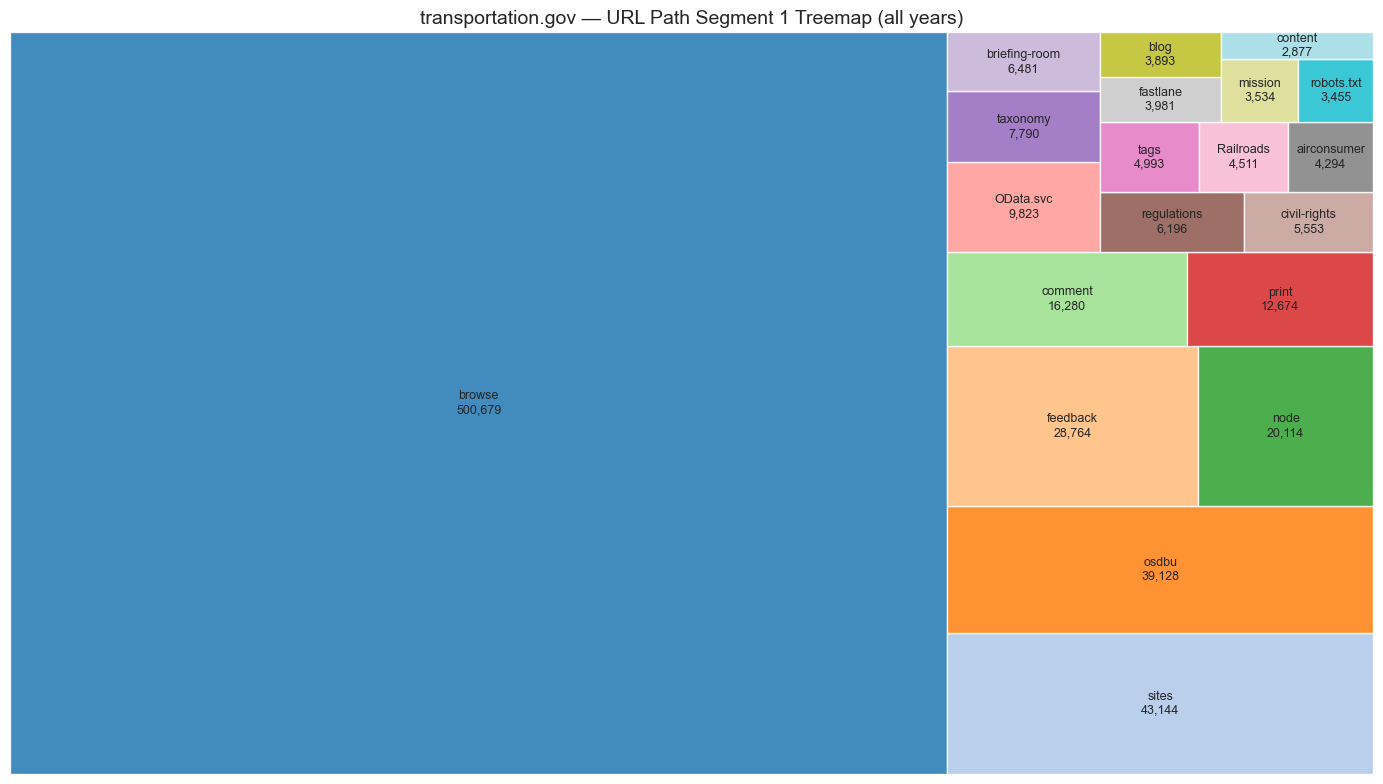

In [28]:
# Viz 7: Path hierarchy treemap (top 20 seg1 paths by total count)
try:
    import squarify
except ImportError:
    print("squarify not installed — run: pip install squarify")
    squarify = None

if squarify:
    tree_data = seg1_pivot[seg1_pivot.index != '(root)'].head(20).copy()
    labels = [f"{name}\n{total:,}" for name, total in zip(tree_data.index, tree_data['total'])]

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = sns.color_palette('tab20', len(tree_data))
    squarify.plot(sizes=tree_data['total'], label=labels, color=colors, alpha=0.85,
                  text_kwargs={'fontsize': 9}, ax=ax)
    ax.set_title('transportation.gov — SURT path_1 Treemap (all years)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

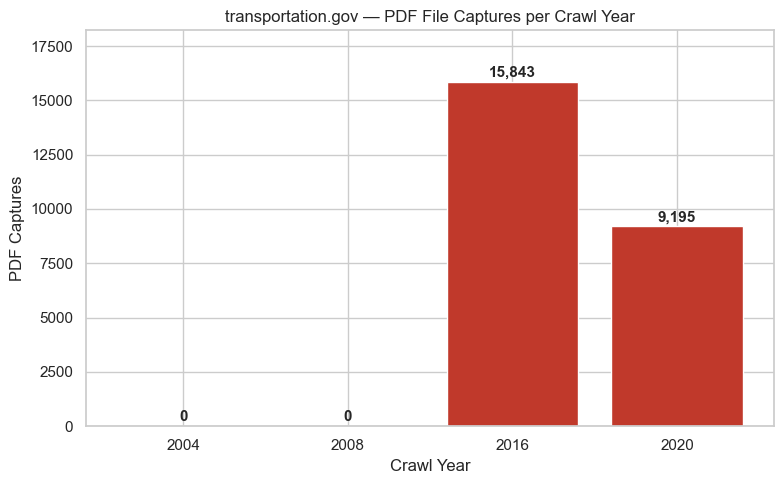

In [29]:
# Viz 8: PDF captures over time
pdf_row = ext_pivot.loc['pdf'] if 'pdf' in ext_pivot.index else None

if pdf_row is not None:
    year_cols = [c for c in ext_pivot.columns if c != 'total']
    pdf_by_year = pdf_row[year_cols]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(pdf_by_year.index, pdf_by_year.values, color='#c0392b')
    for bar, val in zip(bars, pdf_by_year.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF Captures')
    ax.set_xlabel('Crawl Year')
    ax.set_title('transportation.gov — PDF File Captures per Crawl Year')
    ax.set_ylim(0, pdf_by_year.max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("No 'pdf' extension found in data.")

## Content Analysis

In [ ]:
# Analysis 1: Average URL depth per crawl year
depth_stats = transport_con.sql("""
    SELECT
        crawl_year,
        COUNT(*) AS n,
        AVG(len(string_split(trim(regexp_extract(surtkey, '\\)([^?]*)', 1), '/'), '/'))) AS avg_depth,
        MEDIAN(len(string_split(trim(regexp_extract(surtkey, '\\)([^?]*)', 1), '/'), '/'))) AS median_depth,
        MAX(len(string_split(trim(regexp_extract(surtkey, '\\)([^?]*)', 1), '/'), '/'))) AS max_depth
    FROM eot_captures
    WHERE surtkey IS NOT NULL AND surtpath_1 IS NOT NULL AND surtpath_1 != ''
    GROUP BY 1 ORDER BY 1
""").df()

print("URL path depth statistics per crawl year:")
print(depth_stats.to_string(index=False))

# Bar chart of average depth
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(depth_stats['crawl_year'], depth_stats['avg_depth'], color=sns.color_palette('viridis', 4))
for bar, val in zip(bars, depth_stats['avg_depth']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Average SURT path depth')
ax.set_xlabel('Crawl Year')
ax.set_title('transportation.gov — Average SURT path depth per Crawl Year')
plt.tight_layout()
plt.show()

In [ ]:
# Analysis 2: Clean URLs (no extension) vs static files (with extension) per year
clean_vs_static = transport_con.sql("""
    SELECT
        crawl_year,
        SUM(CASE WHEN regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '\\.([a-zA-Z0-9]+)$', 1) = '' THEN 1 ELSE 0 END) AS clean_urls,
        SUM(CASE WHEN regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '\\.([a-zA-Z0-9]+)$', 1) != '' THEN 1 ELSE 0 END) AS static_files,
        COUNT(*) AS total
    FROM eot_captures
    GROUP BY 1 ORDER BY 1
""").df()

clean_vs_static['clean_pct'] = (clean_vs_static['clean_urls'] / clean_vs_static['total'] * 100).round(1)
print("Clean URLs (no extension) vs static files:")
print(clean_vs_static.to_string(index=False))

# Stacked percentage bar
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(clean_vs_static))
width = 0.6

ax.bar(x, clean_vs_static['clean_urls'], width, label='Clean URLs (no ext)', color='#2ecc71')
ax.bar(x, clean_vs_static['static_files'], width, bottom=clean_vs_static['clean_urls'],
       label='Static files (with ext)', color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(clean_vs_static['crawl_year'])
ax.set_ylabel('Captures')
ax.set_xlabel('Crawl Year')
ax.set_title('transportation.gov — Clean URLs vs Static Files per Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
# Analysis 3: Top 30 PDF filenames
pdf_files = transport_con.sql("""
    SELECT
        regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '/([^/]+\\.pdf)$', 1) AS pdf_name,
        crawl_year,
        COUNT(*) AS n
    FROM eot_captures
    WHERE lower(regexp_extract(regexp_extract(surtkey, '\\)([^?]*)', 1), '\\.([a-zA-Z0-9]+)$', 1)) = 'pdf'
    GROUP BY 1, 2
""").df()

pdf_pivot = pdf_files.pivot_table(index='pdf_name', columns='crawl_year', values='n',
                                   aggfunc='sum').fillna(0).astype(int)
pdf_pivot['total'] = pdf_pivot.sum(axis=1)
pdf_pivot = pdf_pivot.sort_values('total', ascending=False)

print(f"Total unique PDF filenames: {len(pdf_pivot):,}")
print(f"\nTop 30 PDFs:")
pdf_pivot.head(30)

In [ ]:
# Analysis 4: Drupal node IDs — count and range per year
node_stats = transport_con.sql("""
    SELECT
        crawl_year,
        COUNT(*) AS node_urls,
        MIN(TRY_CAST(surtpath_2 AS INTEGER)) AS min_node_id,
        MAX(TRY_CAST(surtpath_2 AS INTEGER)) AS max_node_id,
        COUNT(DISTINCT surtpath_2) AS unique_nodes
    FROM eot_captures
    WHERE surtpath_1 = 'node'
    GROUP BY 1 ORDER BY 1
""").df()

print("Drupal /node/ statistics per crawl year:")
print(node_stats.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(node_stats['crawl_year'], node_stats['unique_nodes'], color='#8e44ad')
for bar, val in zip(bars, node_stats['unique_nodes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Unique Drupal Node IDs')
ax.set_xlabel('Crawl Year')
ax.set_title('transportation.gov — Drupal Node IDs per Crawl Year')
plt.tight_layout()
plt.show()

### Export all tables as CSVs

In [34]:
# Save all transportation.gov pivot tables as CSVs
# tables = {
#     'transportation_seg1': seg1_pivot,
#     'transportation_seg2': seg2_pivot,
#     'transportation_seg3': seg3_pivot,
#     'transportation_seg4': seg4_pivot,
#     'transportation_seg5': seg5_pivot,
#     'transportation_extensions': ext_pivot,
#     'transportation_filenames': fname_pivot,
# }

# for name, df in tables.items():
#     path = f'{name}.csv'
#     df.to_csv(path)
#     print(f'  {path} — {len(df):,} rows')

In [35]:
transport_con.close()